### Required Try-It Activity 14.1: Grid Searching Decision Trees 

This try-it focuses on performing a grid search with a `DecisionTreeClassifier`.  As mentioned in the lectures, the grid search for a tree model can get large very easily. In addition to using `GridSearchCV`, scikitlearn implements additional tools that can save energy and offer alternatives to the brute force exhaustive search.  Below, you will compare the performance of some of these alternatives and discuss the time these searches take.  Note that this will be in large part determined by your personal computing power however the relative speed of the searches should be consistent.

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 1.8 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.8 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 4.9 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.3 MB/s eta 0:00:003.3 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.8 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 5.7 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.5 MB/s eta 0:00:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV
from sklearn.preprocessing import LabelEncoder

In [9]:
params = {'max_depth': [],
         'min_samples_split': [],
          'criterion': [],
          'min_samples_leaf': []
         }

In [10]:
dtree = DecisionTreeClassifier()

### Comparing Grid Searches

Below, explore the four grid search options using the same parameter selections for the `DecisionTreeClassifier`. All of the grid searching tools have a `.cv_results_` attribute after fitting that contains information after fitting including time.  Use this to compare the time of each search and discuss what you believe the "best" approach to identifying the hyperparameters of the model are between:

- `GridSearchCV`
- `RandomizedSearchCV`
- `HalvingGridSearchCV`
- `HalvingRandomSearchCV`

Share your results in a plot comparing the different times for searching across the different parameters as well as the score of the different estimators that resulted from the grid search.  

In [12]:
df = pd.read_csv("Try-it_14_1_required_starter/data/Whickham.txt", sep=",")
print(df.head())
print(df.shape)

  outcome smoker  age
0   Alive    Yes   23
1   Alive    Yes   18
2    Dead    Yes   71
3   Alive     No   67
4   Alive     No   64
(1314, 3)


In [13]:
le = LabelEncoder()
df['outcome_enc'] = le.fit_transform(df['outcome'])   # Alive=0, Dead=1
df['smoker_enc']  = le.fit_transform(df['smoker'])    # No=0, Yes=1

X = df[['smoker_enc', 'age']]
y = df['outcome_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# ── 2. Parameter Grid ────────────────────────────────────────────────────────
param_grid = {
    'max_depth':        [2, 3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'criterion':        ['gini', 'entropy'],
    'max_features':     [None, 'sqrt', 'log2'],
}

base_estimator = DecisionTreeClassifier(random_state=42)
cv = 5


In [15]:
# ── 3. Run All Four Searches ─────────────────────────────────────────────────
results = {}


In [16]:
# GridSearchCV
t0 = time.time()
gs = GridSearchCV(base_estimator, param_grid, cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)
results['GridSearchCV'] = {
    'time':  time.time() - t0,
    'score': gs.score(X_test, y_test),
    'best_params': gs.best_params_,
    'cv_results': gs.cv_results_
}

In [17]:
# RandomizedSearchCV
t0 = time.time()
rs = RandomizedSearchCV(base_estimator, param_grid, cv=cv,
                        n_iter=40, random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
results['RandomizedSearchCV'] = {
    'time':  time.time() - t0,
    'score': rs.score(X_test, y_test),
    'best_params': rs.best_params_,
    'cv_results': rs.cv_results_
}

In [18]:
# HalvingGridSearchCV
t0 = time.time()
hgs = HalvingGridSearchCV(base_estimator, param_grid, cv=cv,
                           factor=3, random_state=42, n_jobs=-1)
hgs.fit(X_train, y_train)
results['HalvingGridSearchCV'] = {
    'time':  time.time() - t0,
    'score': hgs.score(X_test, y_test),
    'best_params': hgs.best_params_,
    'cv_results': hgs.cv_results_
}

In [19]:
# HalvingRandomSearchCV
t0 = time.time()
hrs = HalvingRandomSearchCV(base_estimator, param_grid, cv=cv,
                             n_candidates=40, factor=3,
                             random_state=42, n_jobs=-1)
hrs.fit(X_train, y_train)
results['HalvingRandomSearchCV'] = {
    'time':  time.time() - t0,
    'score': hrs.score(X_test, y_test),
    'best_params': hrs.best_params_,
    'cv_results': hrs.cv_results_
}

In [20]:
# ── 4. Print Summary ─────────────────────────────────────────────────────────
print(f"\n{'Method':<25} {'Time (s)':>10} {'Test Score':>12}")
print("-" * 50)
for name, r in results.items():
    print(f"{name:<25} {r['time']:>10.3f} {r['score']:>12.4f}")



Method                      Time (s)   Test Score
--------------------------------------------------
GridSearchCV                   5.797       0.8555
RandomizedSearchCV             0.220       0.8555
HalvingGridSearchCV            1.403       0.8555
HalvingRandomSearchCV          0.252       0.8593


/var/folders/lk/kln21k494rs7y6mxdxppfs7r0000gn/T/ipykernel_22189/1226484524.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(methods, rotation=15, ha='right')
/var/folders/lk/kln21k494rs7y6mxdxppfs7r0000gn/T/ipykernel_22189/1226484524.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(methods, rotation=15, ha='right')


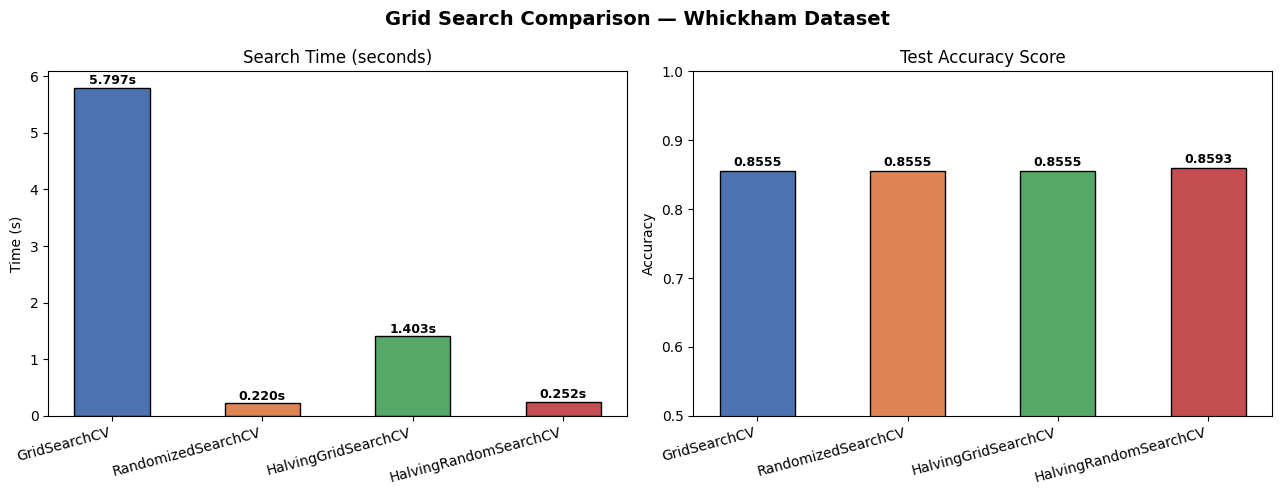

In [23]:
# ── 5. Plot ──────────────────────────────────────────────────────────────────
methods = list(results.keys())
times   = [results[m]['time']  for m in methods]
scores  = [results[m]['score'] for m in methods]
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Grid Search Comparison — Whickham Dataset', fontsize=14, fontweight='bold')

# Time comparison
bars1 = ax1.bar(methods, times, color=colors, edgecolor='black', width=0.5)
ax1.set_title('Search Time (seconds)', fontsize=12)
ax1.set_ylabel('Time (s)')
ax1.set_xticklabels(methods, rotation=15, ha='right')
for bar, t in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{t:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Score comparison
bars2 = ax2.bar(methods, scores, color=colors, edgecolor='black', width=0.5)
ax2.set_title('Test Accuracy Score', fontsize=12)
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.0)
ax2.set_xticklabels(methods, rotation=15, ha='right')
for bar, s in zip(bars2, scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{s:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('grid_search_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── 6. Discussion ─────────────────────────────────────────────────────────────
for name, r in results.items():
    print(f"\n{name} best params:\n  {r['best_params']}")


GridSearchCV best params:
  {'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

RandomizedSearchCV best params:
  {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 2, 'criterion': 'gini'}

HalvingGridSearchCV best params:
  {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 5}

HalvingRandomSearchCV best params:
  {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5, 'criterion': 'entropy'}
